## PCA ANALYSIS FOR PEX-A HOTSPOT

In [1]:
from re import search, compile
from spectrum_preprocessing import pipeline, distribution_Selection
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import pickle as pk
import numpy as np
import os

numlike = compile(r"^-?\d+(\.\d+)?$")

Functions

In [2]:
def averageArea(df):
    # Group by both 'Sample Name' and 'map_x'
    grouped = df.groupby(['Sample Name'])
    
    # Aggregate mean and std
    summary_df = grouped.agg(['mean', 'std']).reset_index()

    return summary_df

def roundWavenumbers(dataframe):
    """
    Function for rounding the wavenumbers so that there is no mismatch between the machine 
    precision of saving the files in Quasar and the wavenumbers output by the FTIR microscope
    """
    numlike = compile(r"^-?\d+(\.\d+)?$")
    numeric_idxs = np.array([c for c in dataframe.columns if numlike.match(str(c).strip())])

    dataframe = dataframe.rename(columns=lambda c: round(float(c), 1) if c in numeric_idxs else c)
    return dataframe

def IR_PCA(input_data, PCs):

    scaler = StandardScaler()
    input_data_scaled = scaler.fit_transform(input_data)
    
    pca = PCA(n_components = PCs)
    data_PCs = pca.fit_transform(input_data_scaled)
    columns_list = ['PC'+ str(x) for x in range(1, PCs+1)]
    PC_df = pd.DataFrame(data = data_PCs,
                                columns = columns_list)
    
    feature_weights = pca.components_
    loadings_df = pd.DataFrame(feature_weights)
    
    print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
    
    return(PC_df, loadings_df)

def PCA_spectra_formatted(df):
    df['variance'] = df['variance'].apply(lambda x: f"{100 * x:.3g}")
    labels = df.loc[:,'components'].values.copy() + " " + df.loc[:, 'variance'].values.astype(str) + "%"

    numlike = compile(r"^-?\d+(\.\d+)?$")
    wavenumbers = np.array([c for c in df.columns if numlike.match(str(c).strip())])

    absorbance = df[wavenumbers].copy()
    absorbance_values = absorbance.values

    return absorbance_values, wavenumbers

def add_df_column(df, column_to_add, column_name):
    df[column_name] = column_to_add
    return df


Import and Format Data

In [3]:
if not os.path.exists("C:/Users/Zach/OneDrive/Documents/Python Scripts/PCA/training_data.csv"):
        filepath = 'C:/Users/Zach/Documents/GitHub/betaVAE_Training/training_data/'

        #file2 = 'SMP65 010 0-100d Hotspot Spectra 800um.csv'
        allFiles = os.listdir(filepath)
        # Take only the files that contain data pertaining to SMP65#010 
        trainingFiles = [file for file in allFiles if file.endswith('.csv') and 'SMP65#010' in file and 'full width' not in file and 'hotspot' not in file]

        trainingFiles = sorted(trainingFiles, key=lambda x: int(search(r'(?<= )(.+?)(?=d)', x).group()))

        print(trainingFiles)
        # Read all of the data and place the dataframes into a list
        trainingDataframeList = [pd.read_csv(filepath+file, low_memory=True, skiprows=[1,2]) for file in trainingFiles]

        masked_trainingDataframeList = []

        for df in trainingDataframeList:
                _, _, mask_selected, modePosition, areaPE = distribution_Selection(df, '1981.7 - 2095.8', 4)
                df[mask_selected] = df[mask_selected].ffill()
                masked_trainingDataframeList.append(df[mask_selected])
        trainingDataframeList = None # Clear memory

        rawTrainingDataframe = pd.concat(
        (
            df.rename(
                columns=lambda c: round(float(c), 1) if numlike.match(str(c).strip()) else c
            )
            for df in masked_trainingDataframeList
        ),
        ignore_index=True
        )

        training_df = pd.concat(masked_trainingDataframeList, ignore_index=True)
        training_df = roundWavenumbers(training_df)
        masked_trainingDataframeList = None # Clear memory of list of dataframes since we have one dataframe now

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        interpDataFramelist = []
        for index, full_row in training_df.iterrows():

                spectra = full_row[wavenumbers]
                metas = full_row.drop(wavenumbers)
                meta_cols = metas.index
                meta_values = metas.to_numpy()

                frequencies = spectra.index.to_numpy(dtype=float)
                frequencies = frequencies[::-1]  # Reverse the order for interpolation

                spectrum = spectra.to_numpy(dtype=float)
                spectrum = spectrum[::-1]  # Reverse the order for interpolation

                frequencies, spectrum = pipeline(frequencies, spectrum)

                cols = np.concatenate([meta_cols, frequencies])
                data = np.concatenate([meta_values, spectrum])

                interpDataFramelist.append(pd.DataFrame(data=[data], columns=cols))

        training_df = pd.concat(interpDataFramelist, ignore_index=True)
        
        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        print(training_df)

        frequencies = [float(wavenumber) for wavenumber in wavenumbers]

        training_df.to_csv("training_data.csv", index=False)

        grouped = training_df.groupby('Sample Name')

        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

else:
        print("Training CSV File already exists.")
        filepath = "C:/Users/Zach/OneDrive/Documents/Python Scripts/PCA/training_data.csv"
        training_df = pd.read_csv(filepath, low_memory=True)

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        grouped = training_df.groupby('Sample Name')
        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

legend_labels = training_df['Sample Name'].unique()
data_handles = []

['SMP65#010 0d 820um.csv', 'SMP65#010 2d 820um.csv', 'SMP65#010 4d 820um.csv', 'SMP65#010 7d 820um.csv', 'SMP65#010 14d 820um.csv', 'SMP65#010 21d 820um.csv', 'SMP65#010 28d 820um.csv', 'SMP65#010 35d 820um.csv', 'SMP65#010 42d 810um.csv', 'SMP65#010 49d 810um.csv', 'SMP65#010 56d 820um.csv', 'SMP65#010 63d 820um.csv', 'SMP65#010 70d 820um.csv', 'SMP65#010 77d 820um.csv', 'SMP65#010 84d 820um.csv', 'SMP65#010 100d 820um.csv']
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max iteration reached!
airpls: max 

Individual Sample PCA

Explained variation per principal component: [0.21781497 0.17850375 0.12401342 0.06625256 0.05612869 0.04450964
 0.03226123 0.02516743 0.0205739  0.01976874]


c:\Users\Zach\anaconda3\envs\tf\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


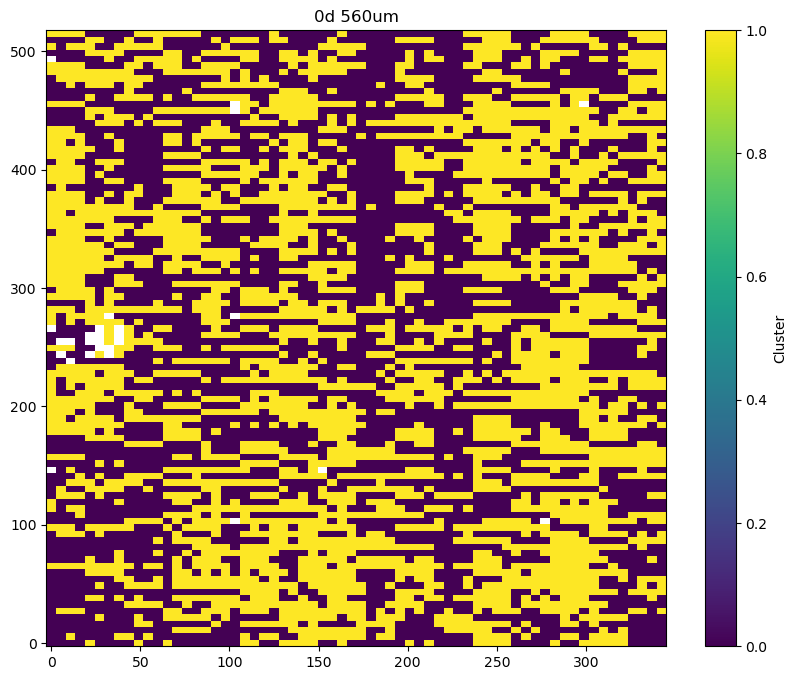

Explained variation per principal component: [0.33864299 0.17897512 0.10248923 0.05638056 0.05051402 0.03847968
 0.02427168 0.02181062 0.02164165 0.01677939]


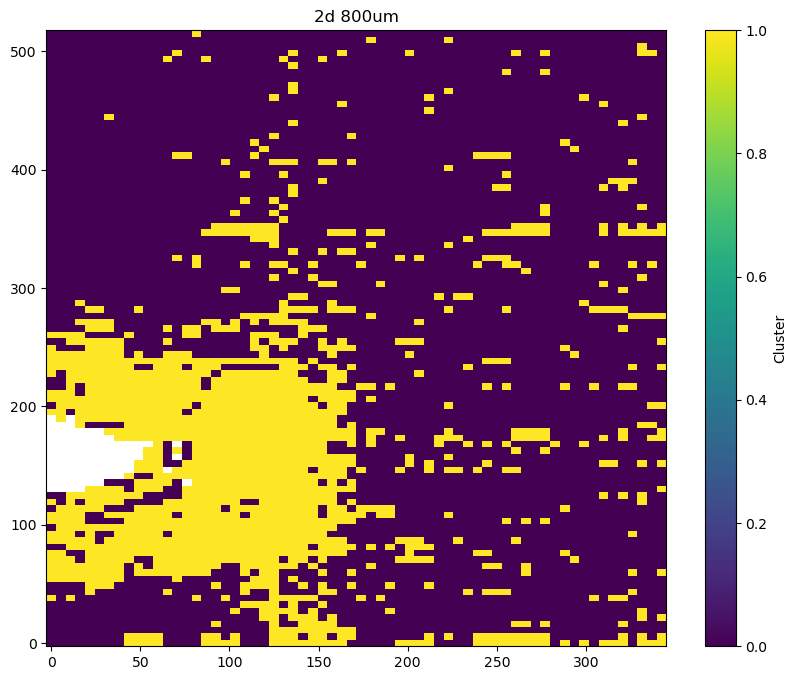

Explained variation per principal component: [0.24897657 0.16785944 0.11224516 0.10180931 0.05725148 0.03903516
 0.03184719 0.02247382 0.02063116 0.0174502 ]


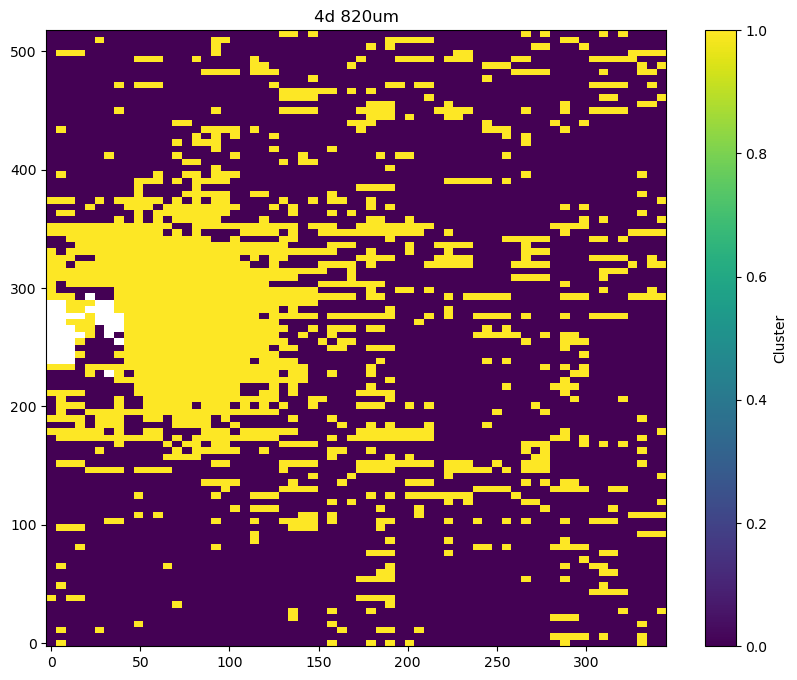

Explained variation per principal component: [0.33841548 0.12336933 0.10005247 0.0922781  0.05833275 0.03632349
 0.03005359 0.02320629 0.01867161 0.01577464]


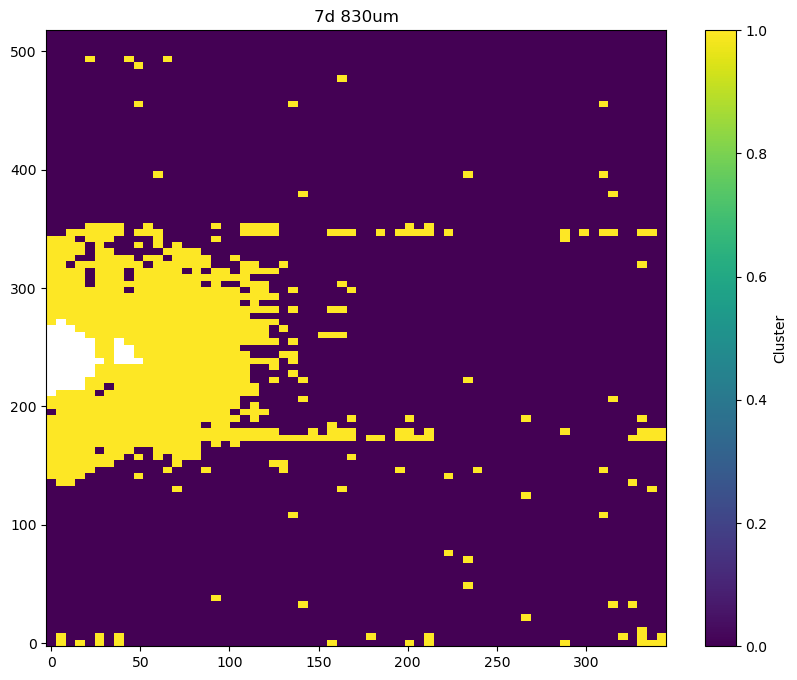

Explained variation per principal component: [0.31973877 0.13950153 0.09921411 0.09606087 0.06086331 0.02893001
 0.02547501 0.02376032 0.02010457 0.01550152]


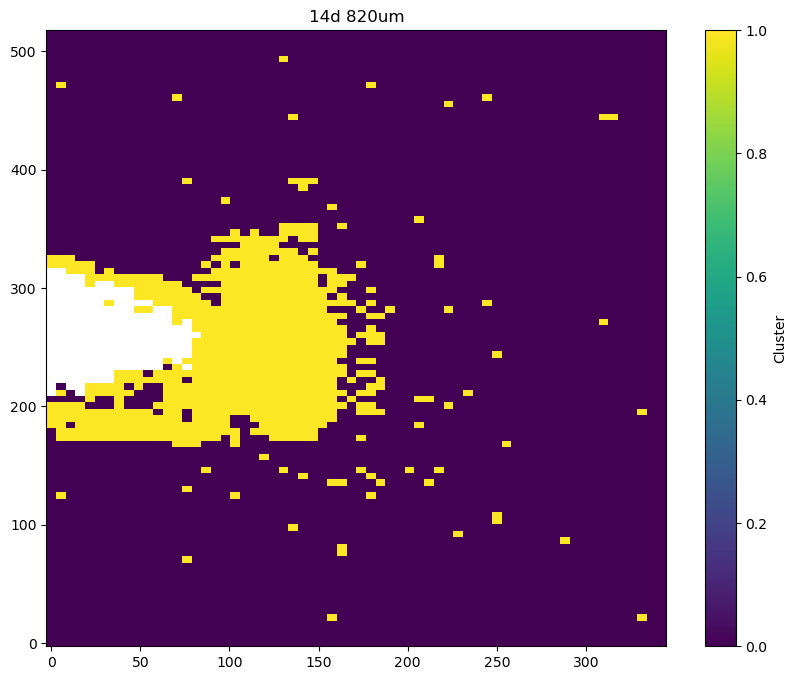

Explained variation per principal component: [0.38327722 0.14049279 0.07676062 0.06033675 0.05763715 0.04442646
 0.0262263  0.01963307 0.0185322  0.01500675]


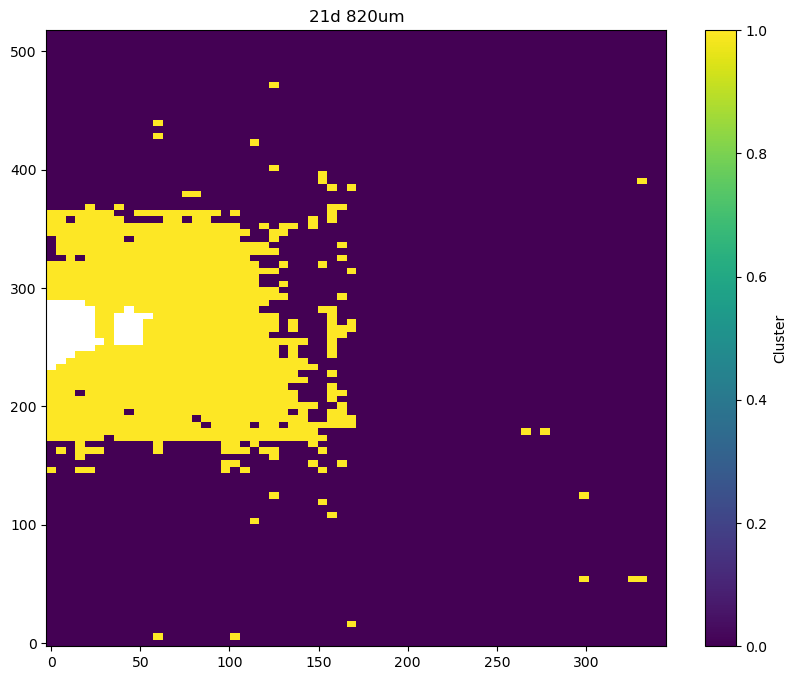

Explained variation per principal component: [0.45633978 0.09676045 0.09057605 0.07144315 0.04301988 0.02284748
 0.02032095 0.01929418 0.01632702 0.01156387]


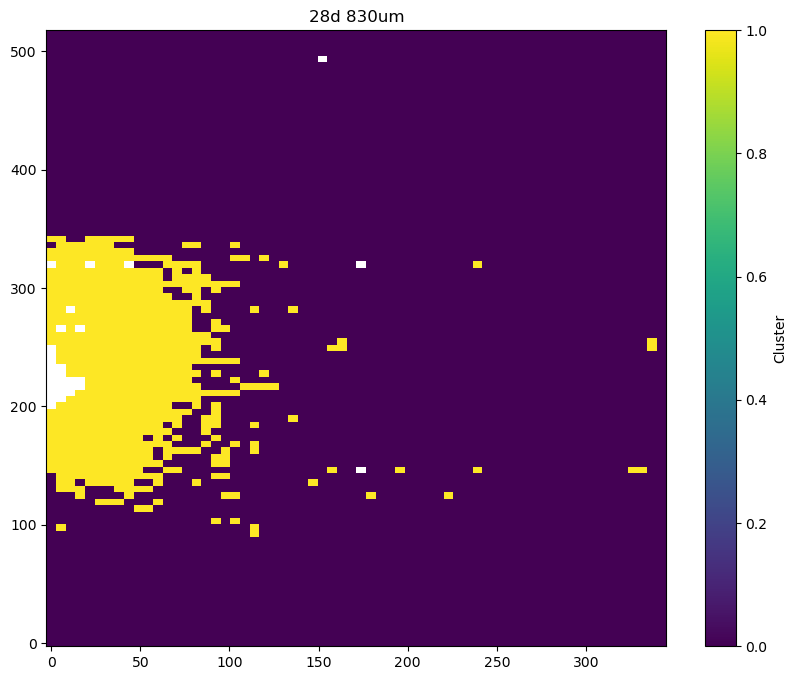

Explained variation per principal component: [0.42910482 0.12991119 0.06506288 0.06022473 0.04153718 0.03362847
 0.0231861  0.01816566 0.01743336 0.01386536]


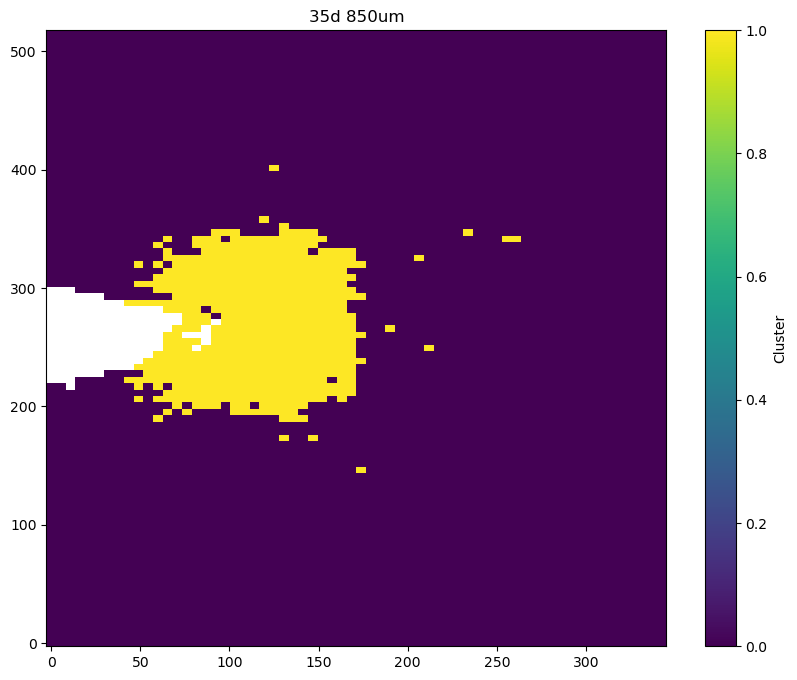

Explained variation per principal component: [0.47919544 0.08577095 0.06660725 0.05511781 0.04960788 0.03833285
 0.02893201 0.01724802 0.01473068 0.01214254]


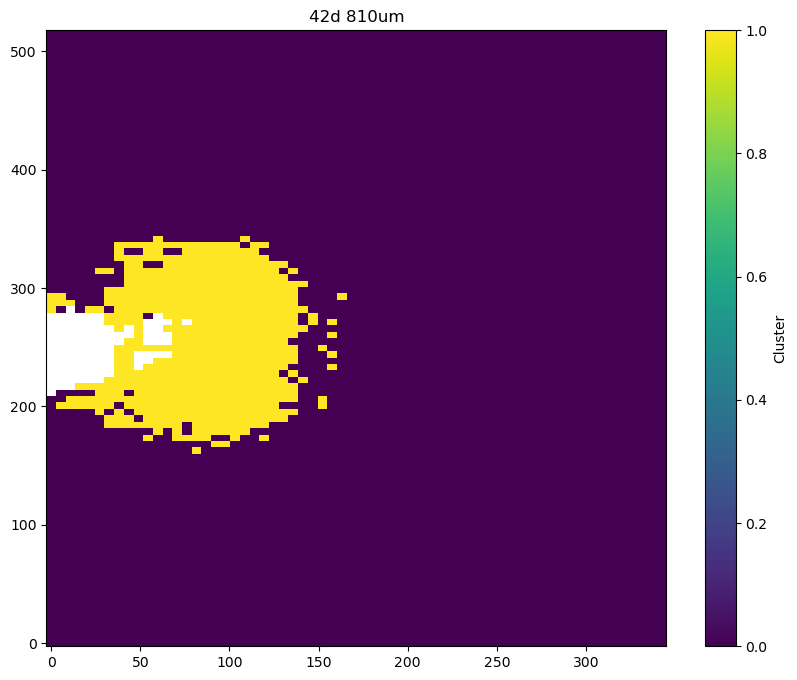

Explained variation per principal component: [0.46357751 0.11359679 0.08225088 0.06082518 0.03967653 0.03180923
 0.02203144 0.01990212 0.01475767 0.01167322]


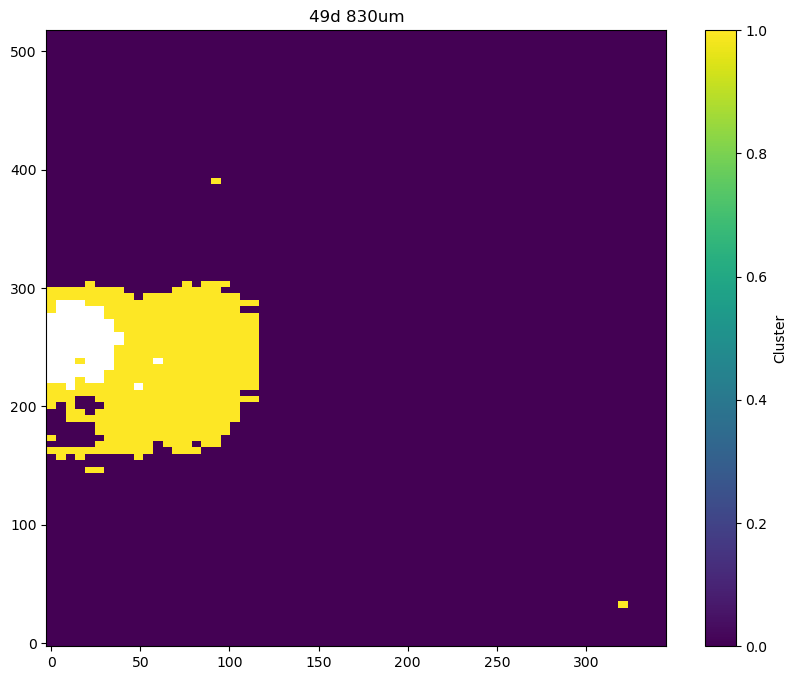

Explained variation per principal component: [0.48653768 0.14668025 0.04862686 0.04685206 0.03682214 0.03372556
 0.024526   0.01536277 0.01433028 0.01244043]


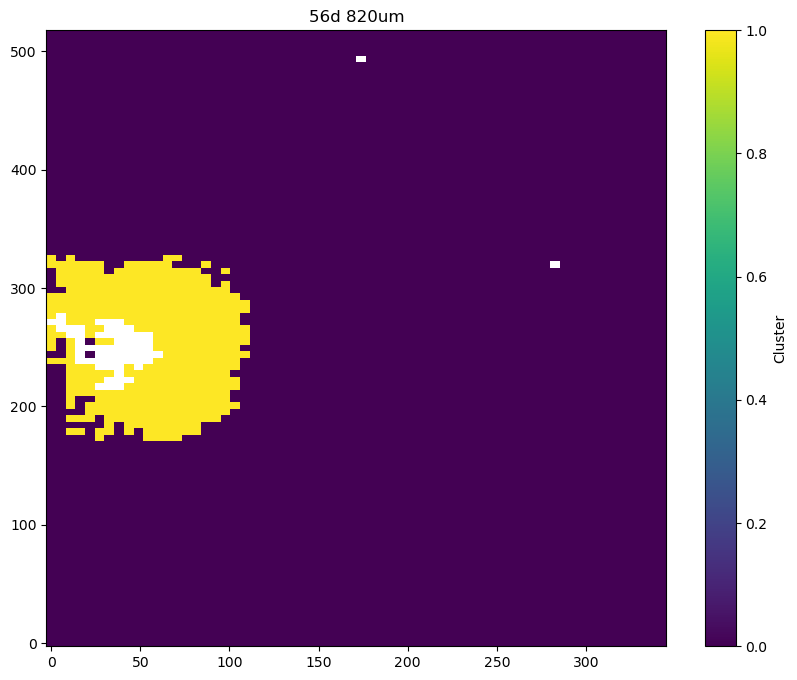

Explained variation per principal component: [0.47971497 0.1574792  0.06537025 0.05744859 0.03431788 0.03133608
 0.02023684 0.01749577 0.01538381 0.01170959]


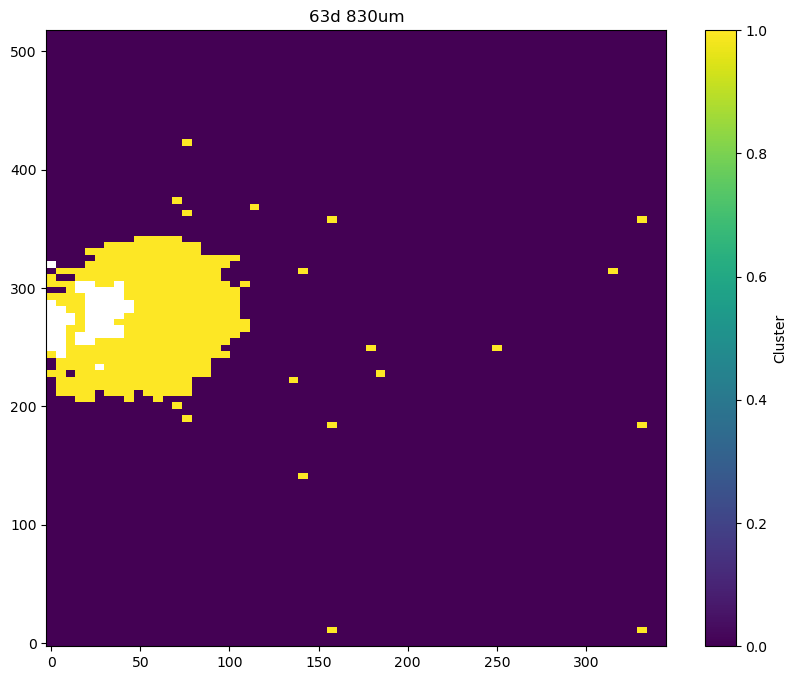

Explained variation per principal component: [0.50206374 0.15601357 0.06764687 0.04920601 0.03180898 0.02596638
 0.0189272  0.0150268  0.01278547 0.01107428]


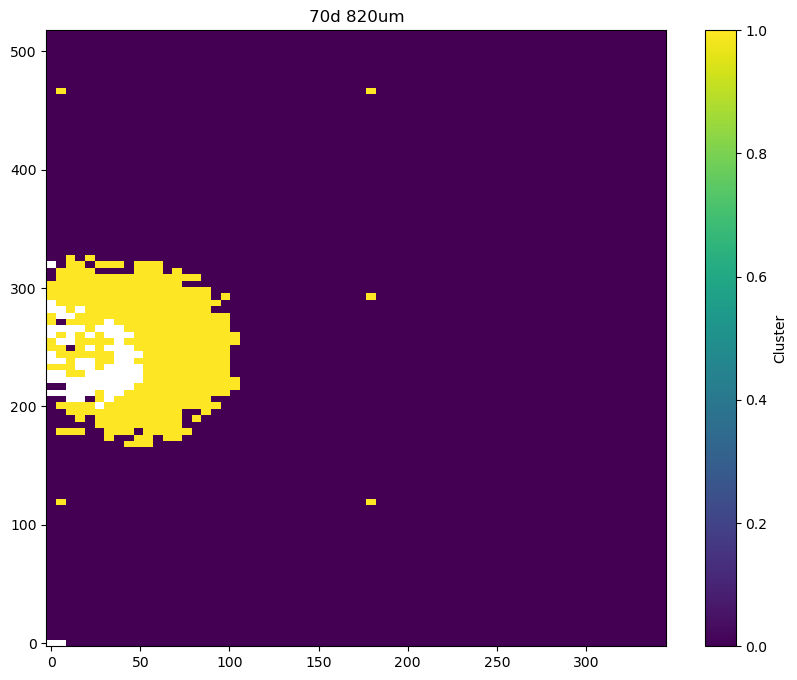

Explained variation per principal component: [0.47590506 0.13589192 0.08726452 0.05602578 0.03189185 0.02642197
 0.02190237 0.0177889  0.01410455 0.01119292]


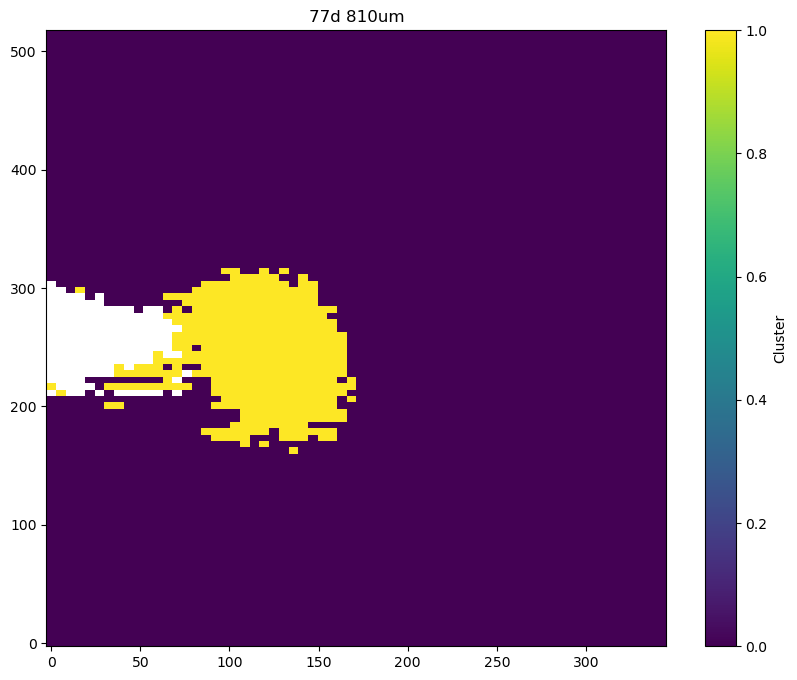

Explained variation per principal component: [0.47785365 0.12295967 0.07843945 0.05952954 0.03494009 0.02515576
 0.02093694 0.01765564 0.01698334 0.01446724]


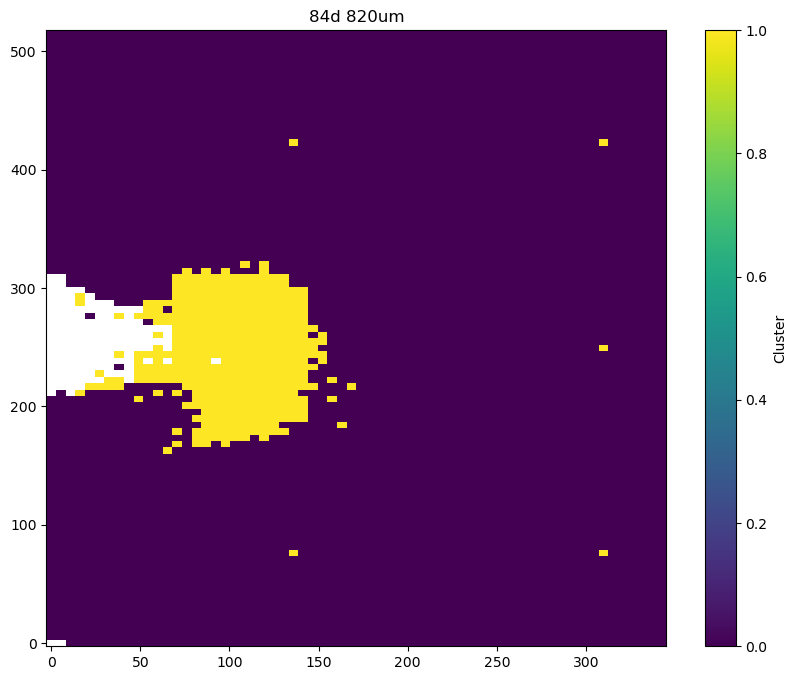

Explained variation per principal component: [0.41074121 0.11834957 0.08032578 0.07236377 0.05345504 0.03814518
 0.0233701  0.02239954 0.01339411 0.012477  ]


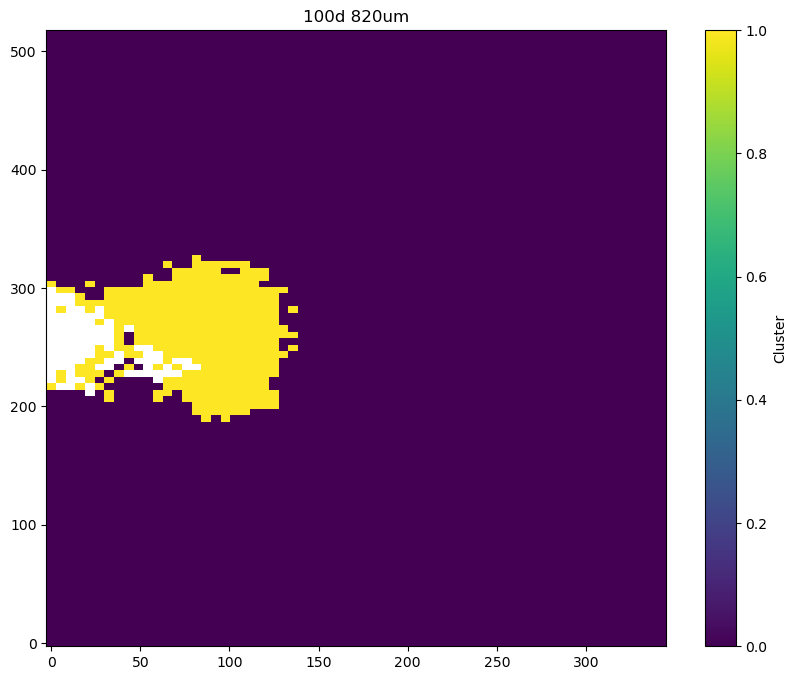

In [4]:
from sklearn.cluster import KMeans
os.environ["OMP_NUM_THREADS"] = "2" # Defining number of threads to avoid memory leak in Kmeans on Windows
from sklearn.metrics import silhouette_score

list_of_labels = {}
for key in keys:
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs)

    PC_df = PCA_output[0]
    loadings_df = PCA_output[1]

    kmeans = KMeans(n_clusters=2, random_state=42).fit(PC_df.values)
    labels = kmeans.fit_predict(PC_df)
    # Arange the clusters by the consumption level, or the amount of data points the cluster contains
    idx = np.argsort(kmeans.cluster_centers_.sum(axis=1))
    lut = np.zeros_like(idx)
    lut[idx] = np.arange(2)

    training_df = training_df.copy()
    training_df["cluster"] = lut[labels]
    dfs[key] = training_df

    Z = (training_df.pivot(index="map_y", columns="map_x", values="cluster").sort_index(ascending=True).values)

    plt.figure(figsize=(10, 8))

    plt.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'{key}')
    plt.colorbar(label="Cluster")

    plt.show()

Plot Average Spectra of Clusters

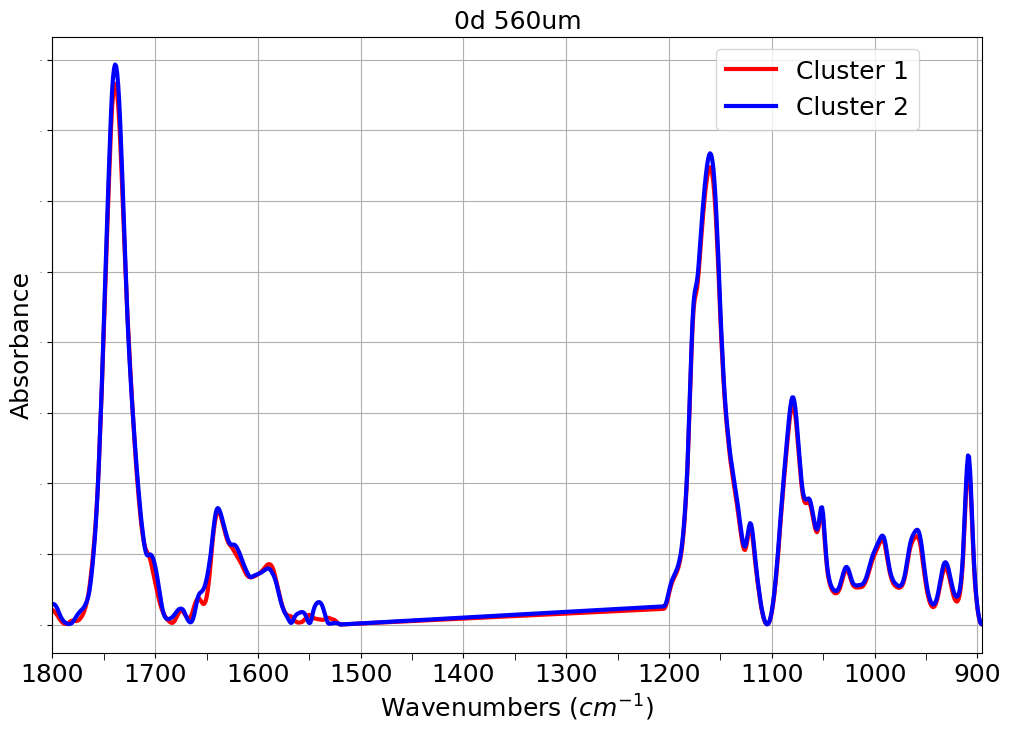

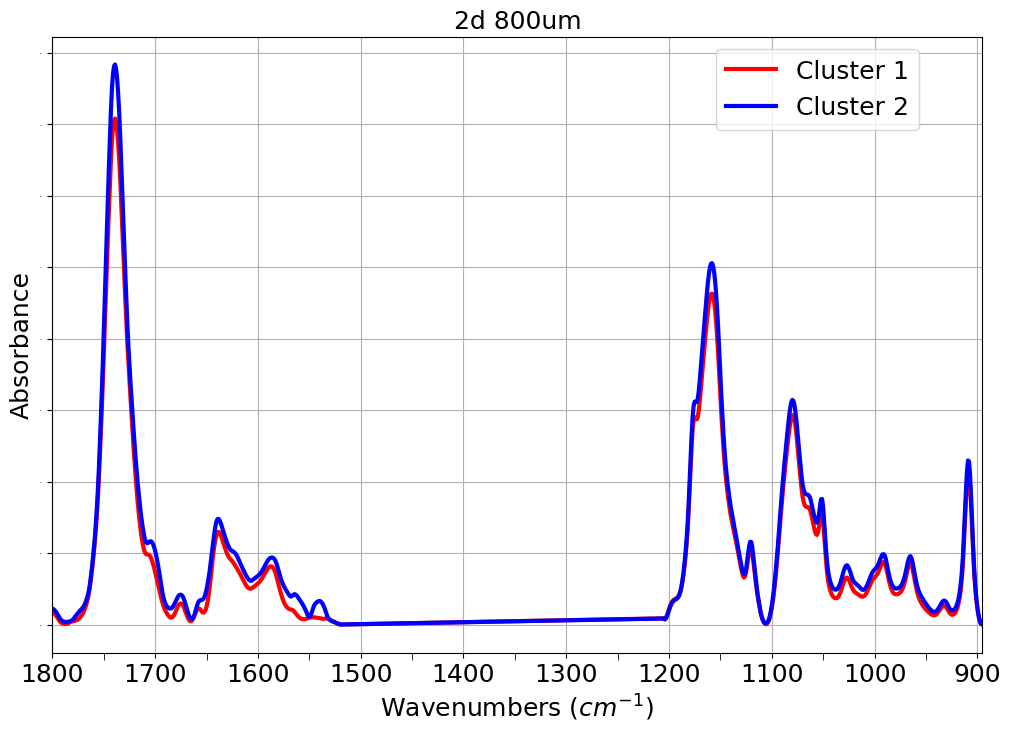

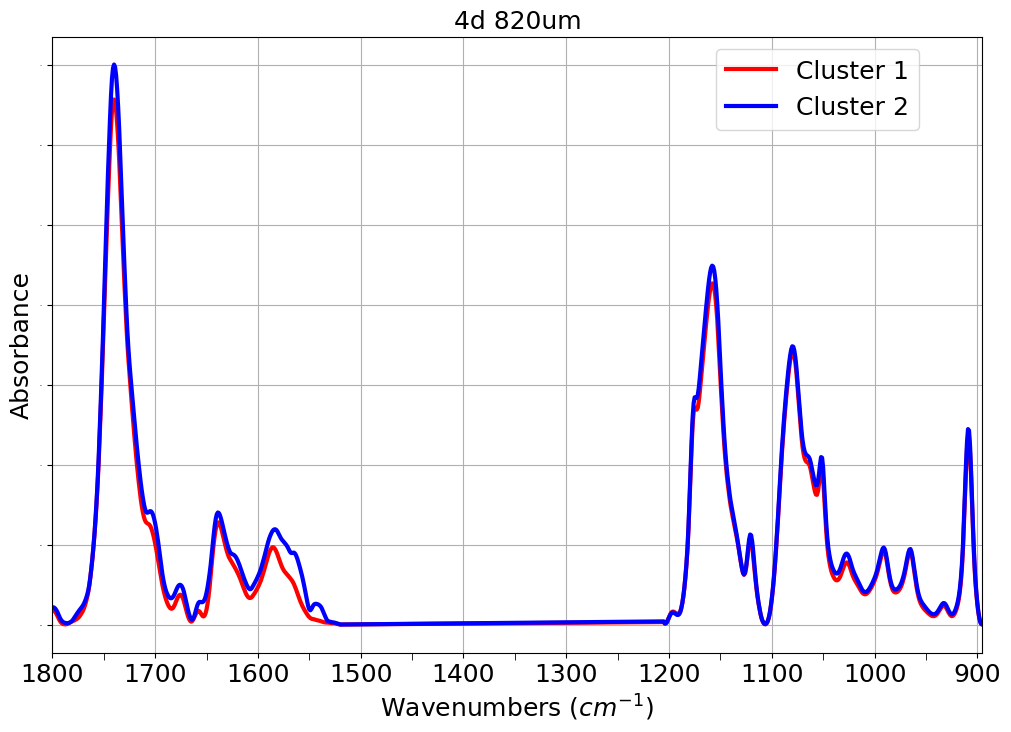

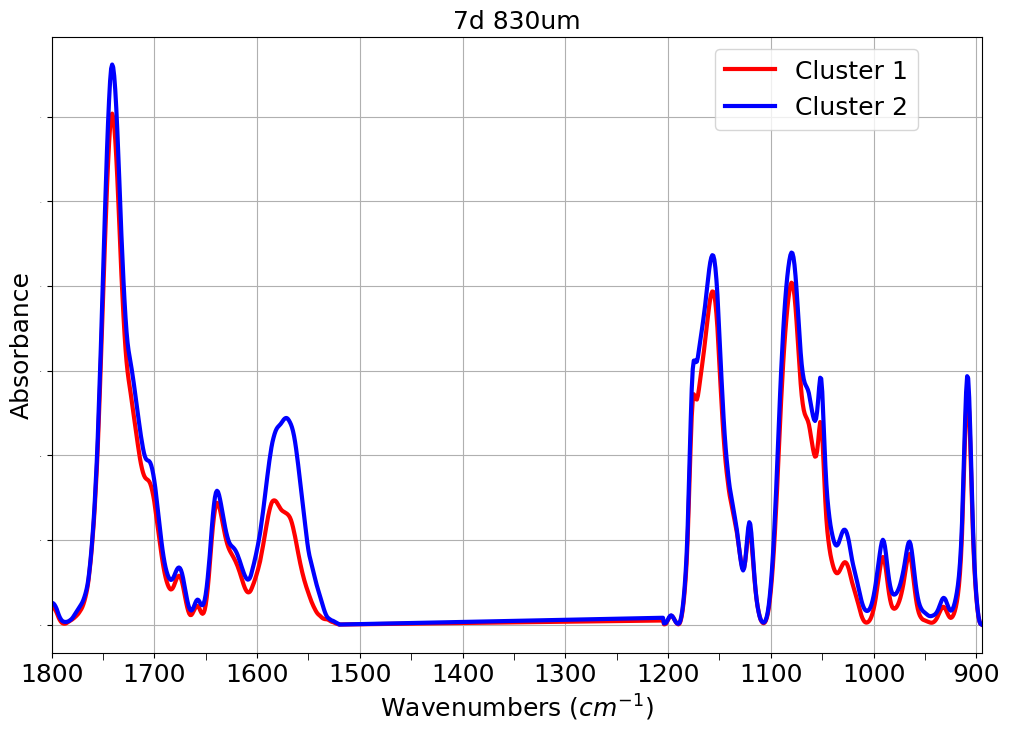

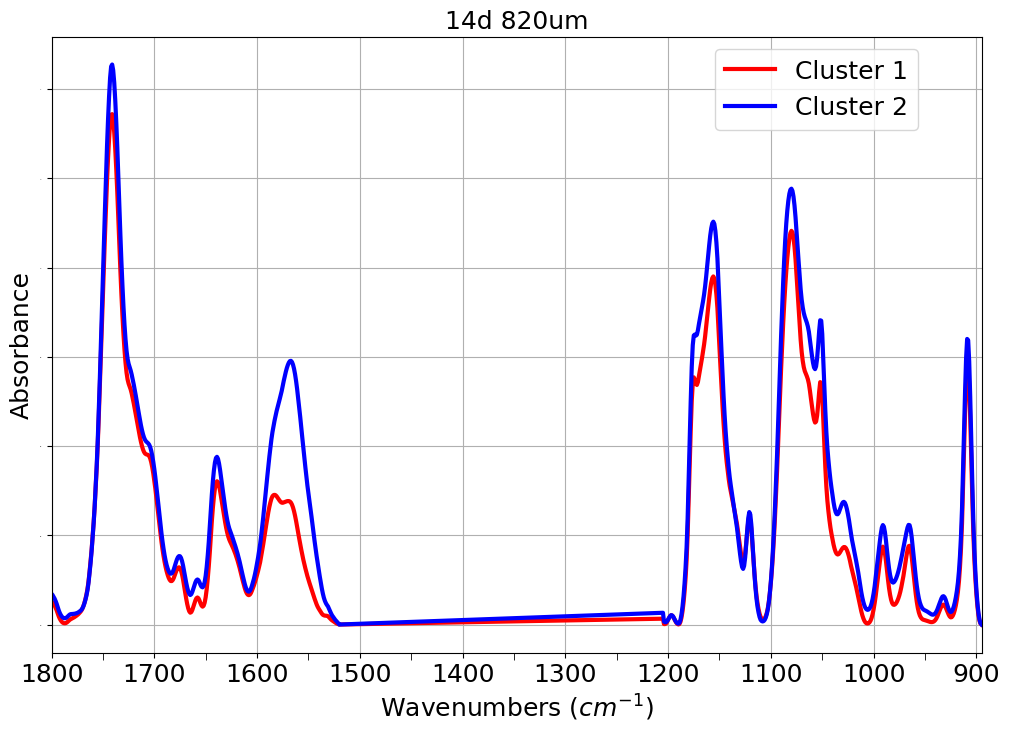

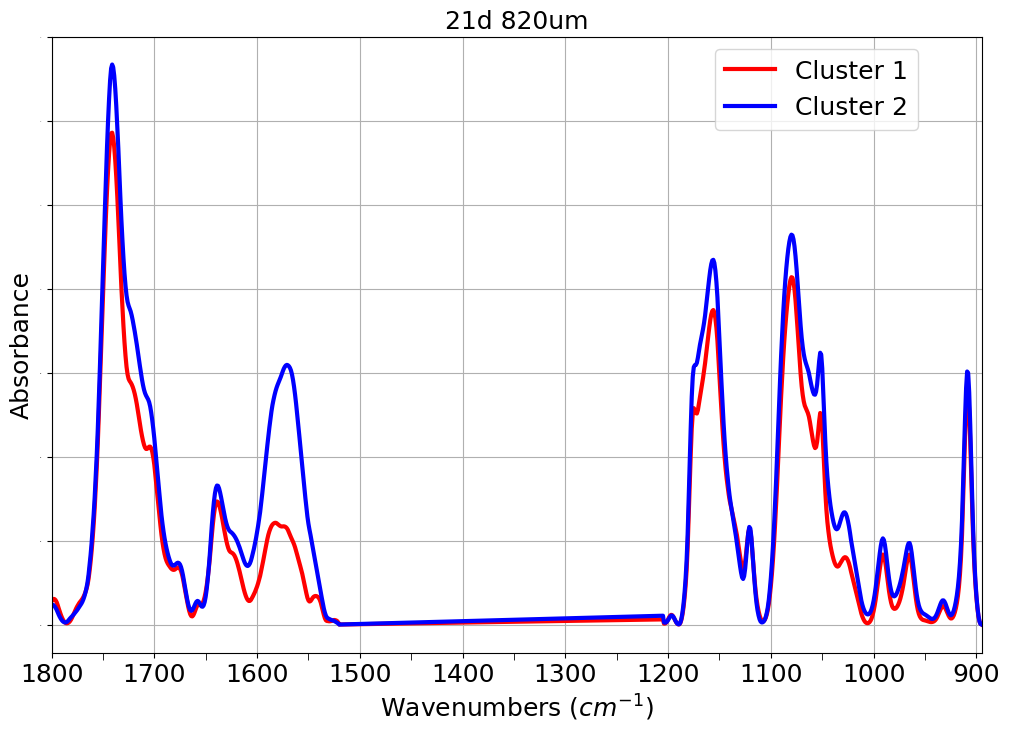

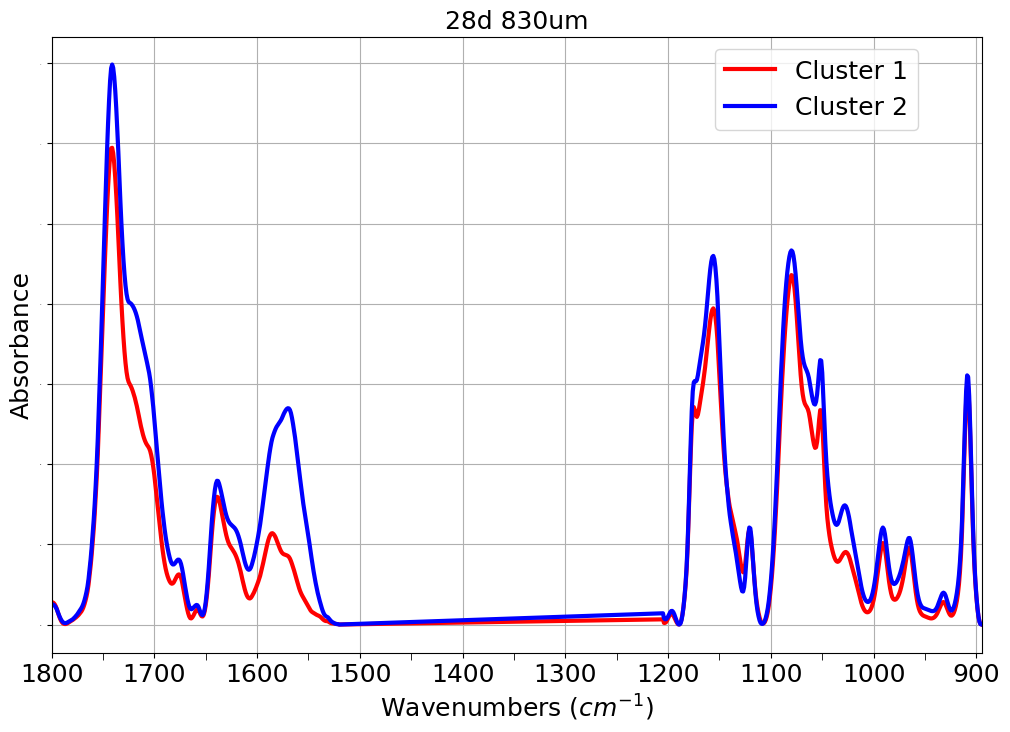

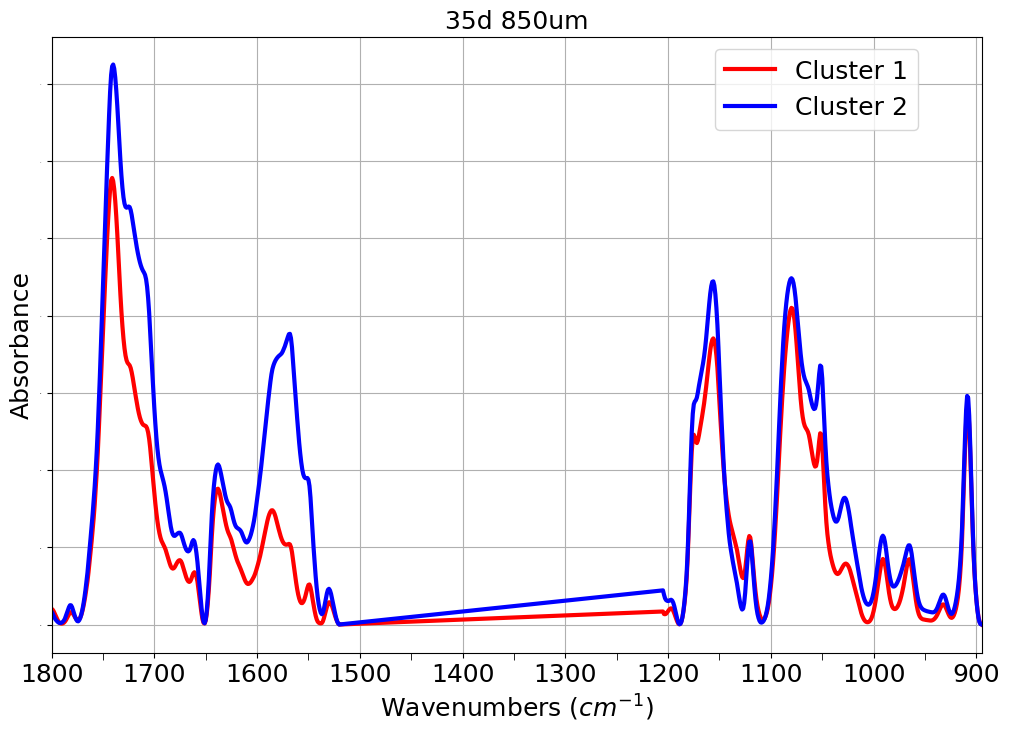

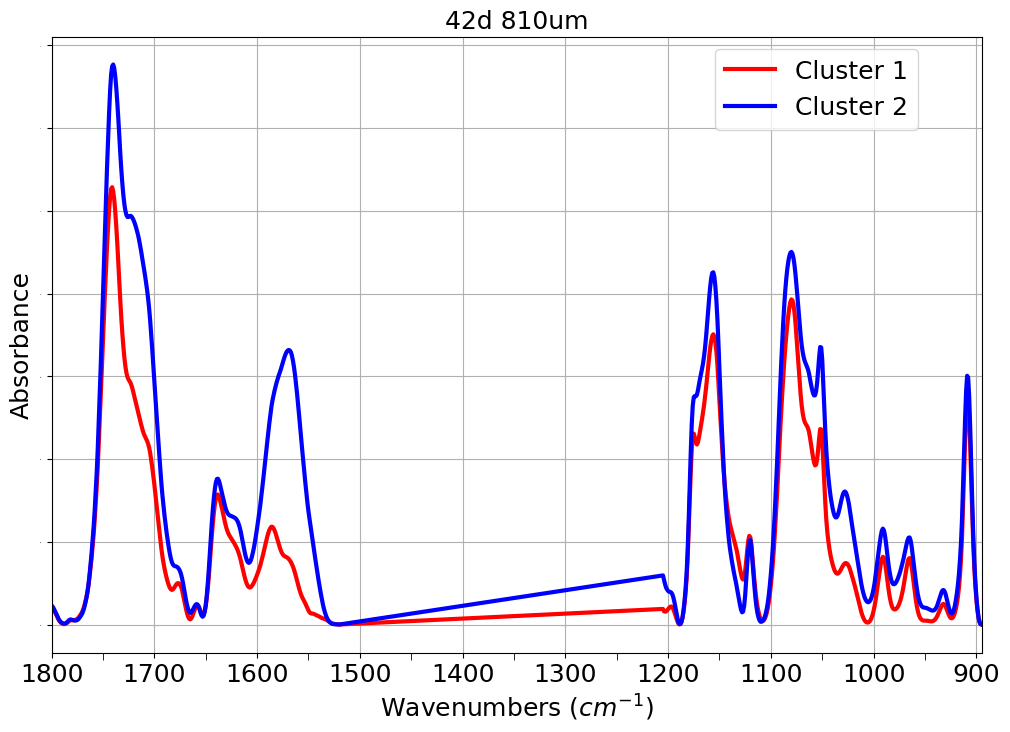

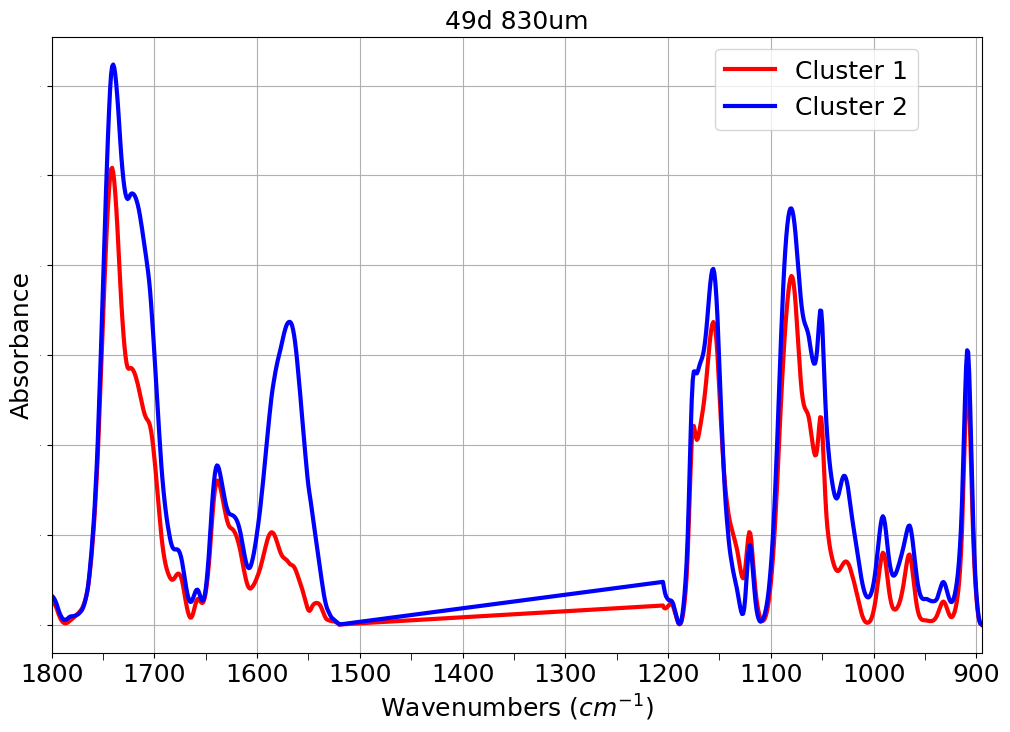

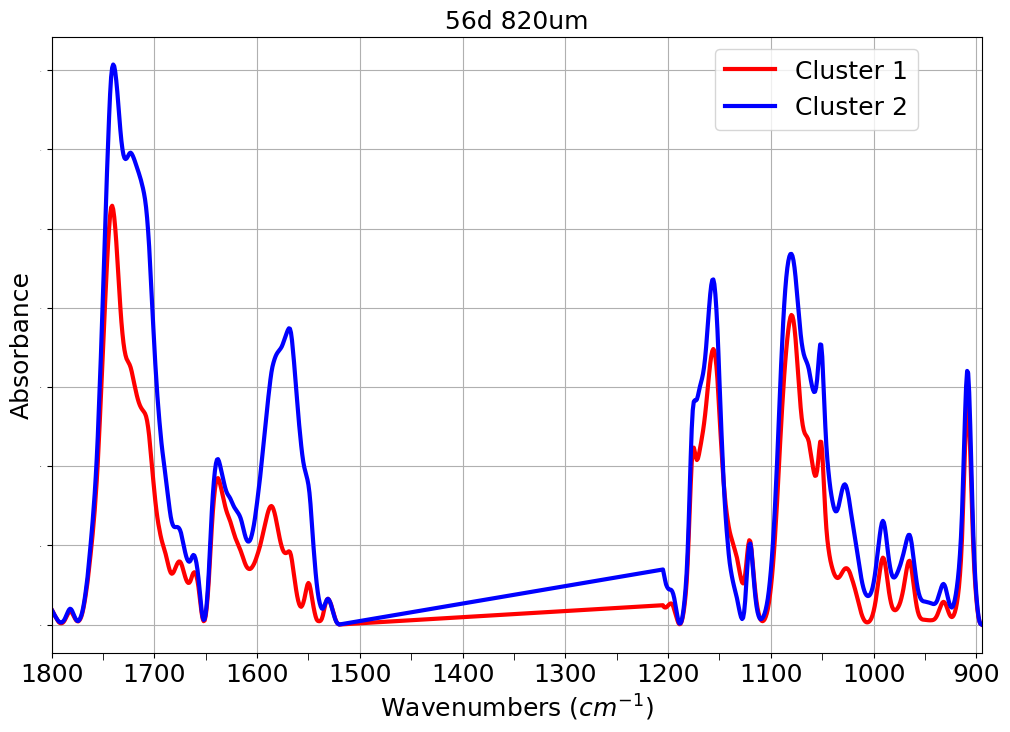

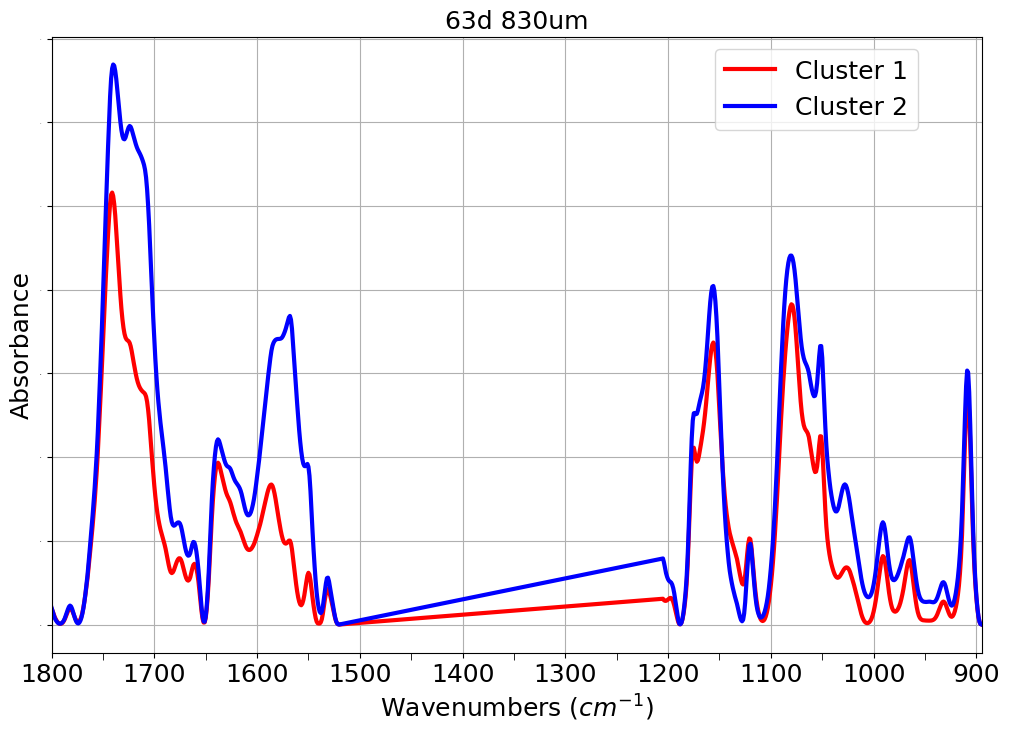

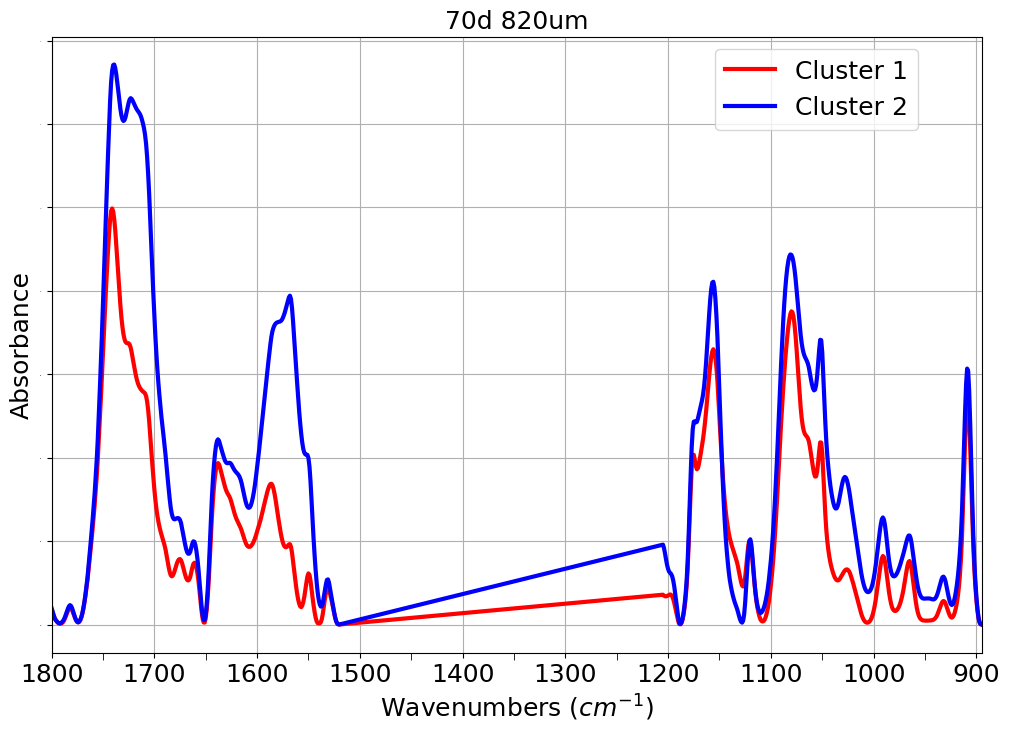

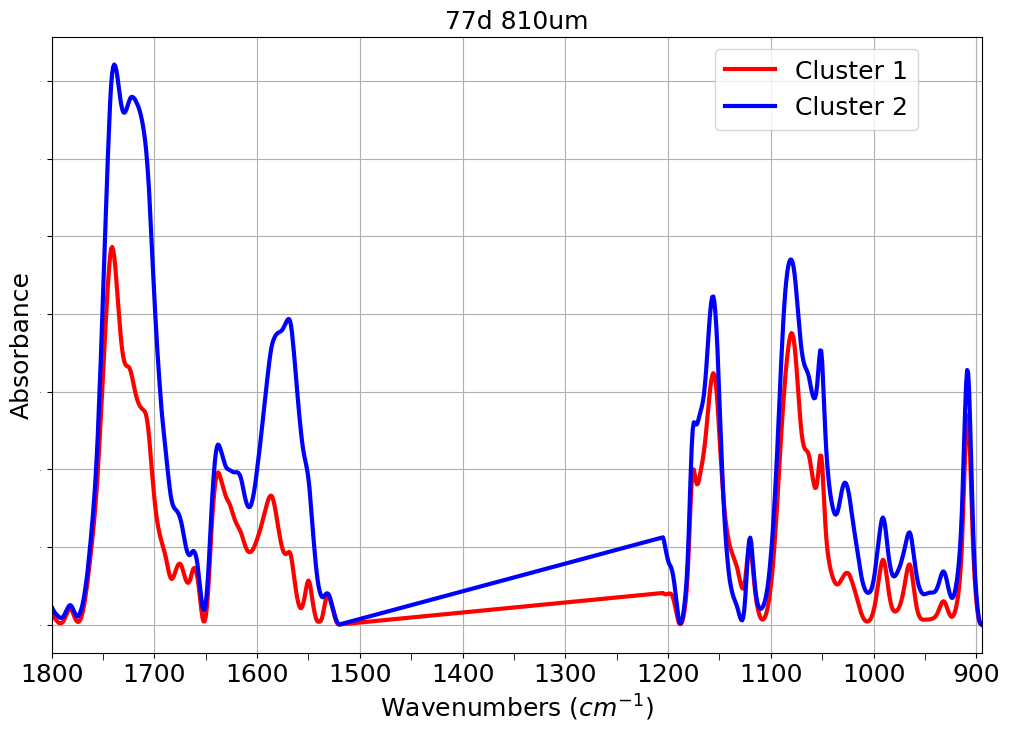

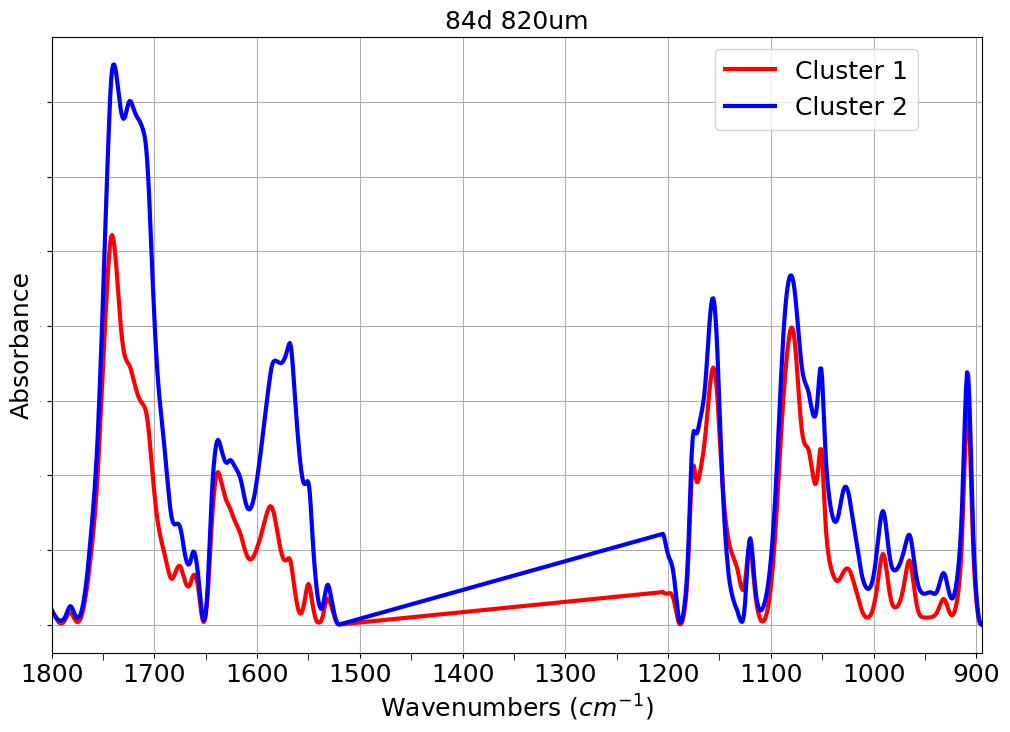

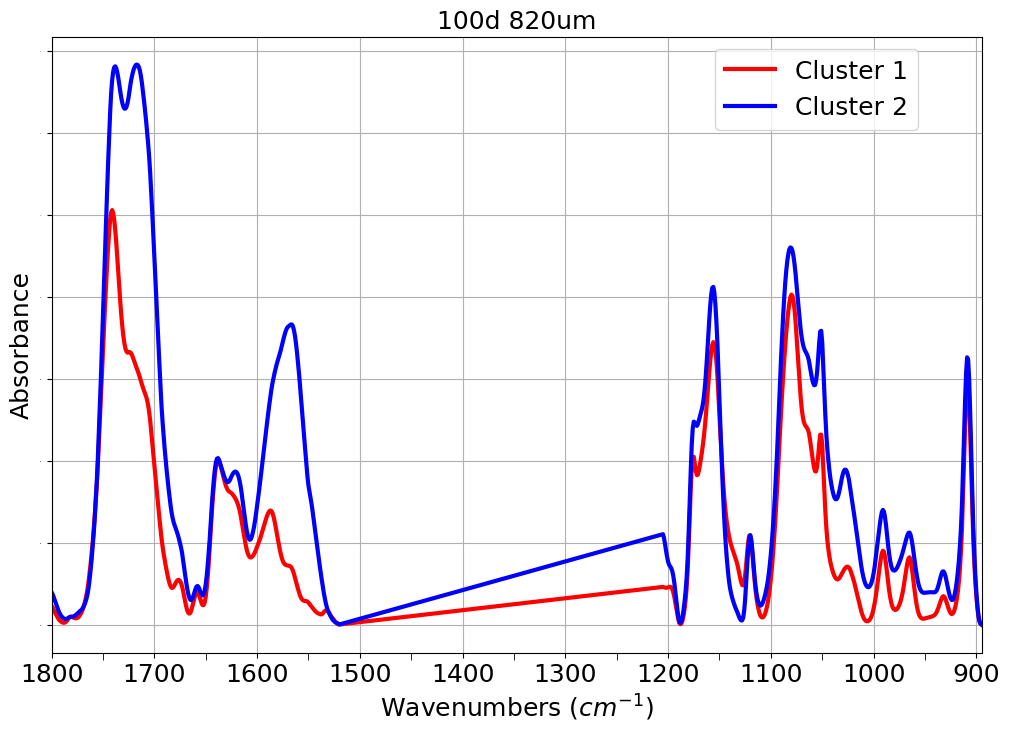

In [5]:
cluster1_spectra = []
cluster2_spectra = []

for key in keys: 
    training_df = dfs[key]

    clustered_df = training_df.groupby('cluster').mean(numeric_only=True)

    clustered_spectra = clustered_df[wavenumbers]
    frequencies = wavenumbers.astype(float)

    cluster1_spectra.append(clustered_spectra.values[0].astype(float))
    cluster2_spectra.append(clustered_spectra.values[1].astype(float))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_ylabel('Absorbance', fontsize=18)
    ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
    ax.set_title(key, fontsize=18)
    ax.plot(frequencies, clustered_spectra.values[0].astype(float), color='r', linewidth=3)
    ax.plot(frequencies, clustered_spectra.values[1].astype(float), color='b', linewidth=3)
    
    ax.tick_params(which='major', axis='x', labelsize=18)
    ax.tick_params(which='minor', axis='x', length=5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.legend(labels=['Cluster 1', 'Cluster 2'],
            fontsize=18, loc='upper left', 
            bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
    ax.tick_params(axis='y', labelsize=0)

    ax.set_xlim(frequencies[-1], frequencies[0])
    ax.grid(True)

Plotting the spectra of each Cluster as a Function of Time

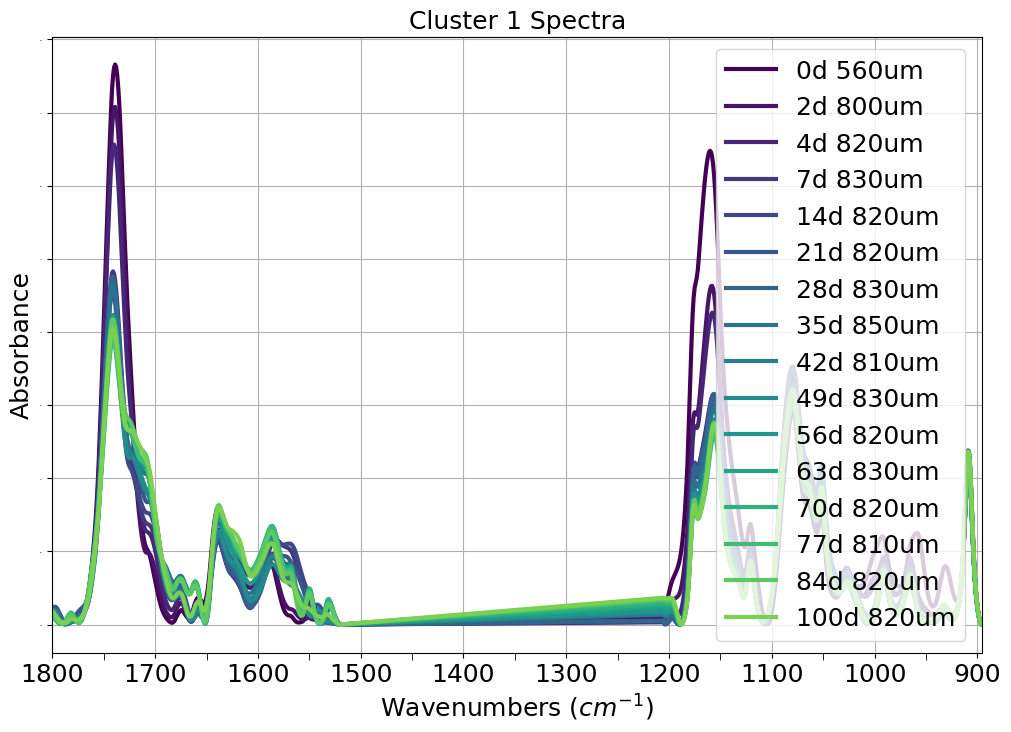

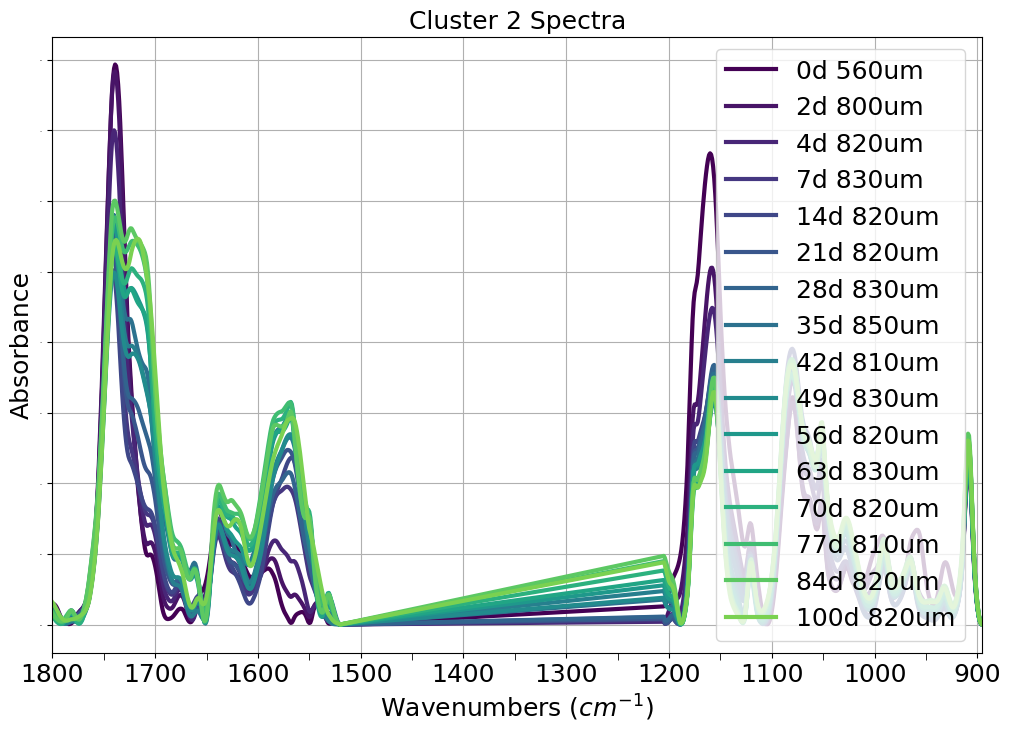

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 1 Spectra", fontsize=18)

for i in range(len(cluster1_spectra)):
        ax.plot(frequencies, cluster1_spectra[i], color=colors[i], linewidth=3)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=keys,
        fontsize=18, loc='upper left', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)


fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 2 Spectra", fontsize=18)

for i in range(len(cluster2_spectra)):
        ax.plot(frequencies, cluster2_spectra[i], color=colors[i], linewidth=3)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=keys,
        fontsize=18, loc='upper left', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)    